In [7]:
import itertools
import numpy as np
import pandas as pd
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, BayesianRidge, LassoCV, ElasticNetCV
from sklearn.svm import SVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from math import ceil

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

In [8]:
spin_df = pd.read_csv("./data/PHIP_Spin_Features.csv", index_col="LABEL")
qsar_df = pd.read_csv("./data/PHIP_QSAR_Features.csv", index_col="LABEL")
dft_df = pd.read_csv("./data/PHIP_DFT_Features.csv", index_col="LABEL")

print(spin_df.shape)
print(qsar_df.shape)
print(dft_df.shape)

RESPONSE_LABEL = 'SNE'
y_df = spin_df[RESPONSE_LABEL].apply(lambda x: np.log(x) if x > 0 else 0)  # log-transform the response variable
# y_df = spin_df[RESPONSE_LABEL]

X_df = pd.concat([spin_df, qsar_df, dft_df], axis=1)
X_df.drop(columns=RESPONSE_LABEL, inplace=True)

# 低方差过滤 和 Spearman 相关性过滤（在整个数据集上做，非训练集）
X_var = X_df.var()
low_var_features = X_var[X_var < 1e-5].index.tolist()
X_df = X_df.drop(columns=low_var_features)

# 标准化
scaler = StandardScaler()
X_df = pd.DataFrame(scaler.fit_transform(X_df), columns=X_df.columns, index=X_df.index)

X = X_df.corr().abs()
upper_tri = X.where(np.triu(np.ones(X.shape), k=1).astype(bool))
high_corr_features = [col for col in upper_tri.columns if any(upper_tri[col] > 0.85)]
X_df = X_df.drop(columns=high_corr_features)


result_list = []

for col in X_df.columns:
    X_temp = sm.add_constant(X_df[[col]])
    y_temp = y_df

    model = sm.OLS(y_temp, X_temp).fit()

    r2 = model.rsquared
    p_value = model.pvalues[col]
    coef = model.params[col]

    result_list.append({
        "features": col,
        "R2": r2,
        "p_value": p_value,
        "coef": coef
    })


feature_stats_df = pd.DataFrame(result_list)
feature_stats_df = feature_stats_df.sort_values(by="R2", ascending=False)

significant_features = feature_stats_df[(feature_stats_df["R2"]) > 0.2]
display(feature_stats_df.head(5))

# R^2 过滤（在整个数据集上做，非训练集）
r2_scores = {}
for col in X_df.columns:
    lr = LinearRegression()
    lr.fit(X_df[[col]], y_df)
    r2_scores[col] = lr.score(X_df[[col]], y_df)

selected_features = [k for k,v in r2_scores.items() if v > 0.2]  # 阈值可调
    
X_df = X_df[selected_features]

print(f"After variance and correlation filtering, {X_df.shape[1]} features remain.")
print(f"Remaining features: {X_df.columns.tolist()}")

(18, 9)
(18, 110)
(18, 52)


,features,R2,p_value,coef
52,C#C_C_2_Fukui-,0.449302,0.002334,0.907798
46,Sterimol_L_C2,0.343602,0.010571,-0.793868
4,Molecule Weight,0.271775,0.026509,-0.706033
0,CSD,0.200777,0.062202,-0.606844
31,ESP All variance (kcal/mol)^2_C1,0.170715,0.088337,0.559571


After variance and correlation filtering, 4 features remain.
Remaining features: ['CSD', 'Molecule Weight', 'Sterimol_L_C2', 'C#C_C_2_Fukui-']


In [9]:
sns.set_theme(style="ticks", context="notebook", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['mathtext.default'] = 'regular'

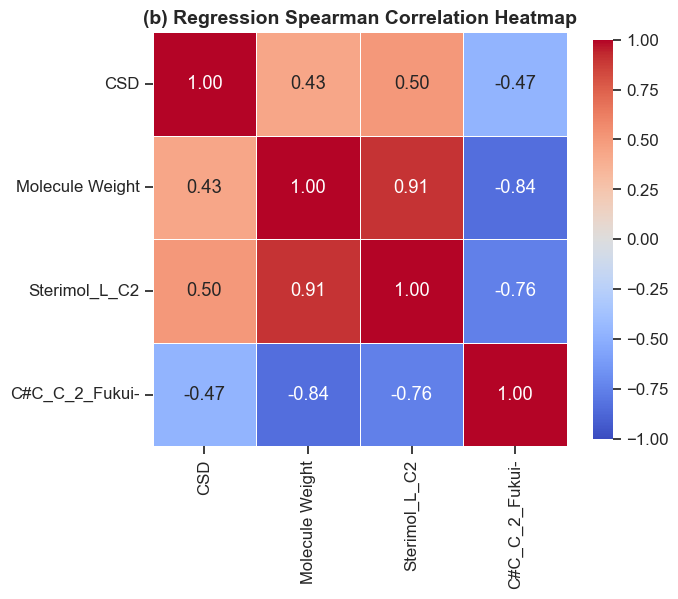

In [3]:
corr = X_df.corr(method='spearman')

fig = plt.figure(figsize=(7,7))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.7})
plt.title("(b) Regression Spearman Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig("clf_heatmap.pdf", dpi=330)
fig.savefig("clf_heatmap.svg", dpi=330)
plt.show()

[MLR search] Evaluating total 10 combinations for sizes (2, 3)...
[MLR search] Searching 2-variable equations...
[MLR search] Searching 3-variable equations...

[Best MLR equation from 2/3-variable search]
Number of variables: 2
Features: ['CSD', 'C#C_C_2_Fukui-']
features           (CSD, C#C_C_2_Fukui-)
N_features                             2
Feature_1                            CSD
Feature_2                 C#C_C_2_Fukui-
Feature_3                           None
Train_R2                        0.504059
Train_MAE                        0.79773
Train_RMSE                      0.953751
LOOCV_Q2                         0.26785
CV_MAE                          0.955453
CV_RMSE                         1.158831
CV_Pearson_r                    0.563085
CV_Pearson_p                    0.014969
CV_Spearman_rho                 0.702786
CV_Spearman_p                   0.001143
Name: 0, dtype: object

Top 10 best MLR equations (2~3 variables):
                                           features  

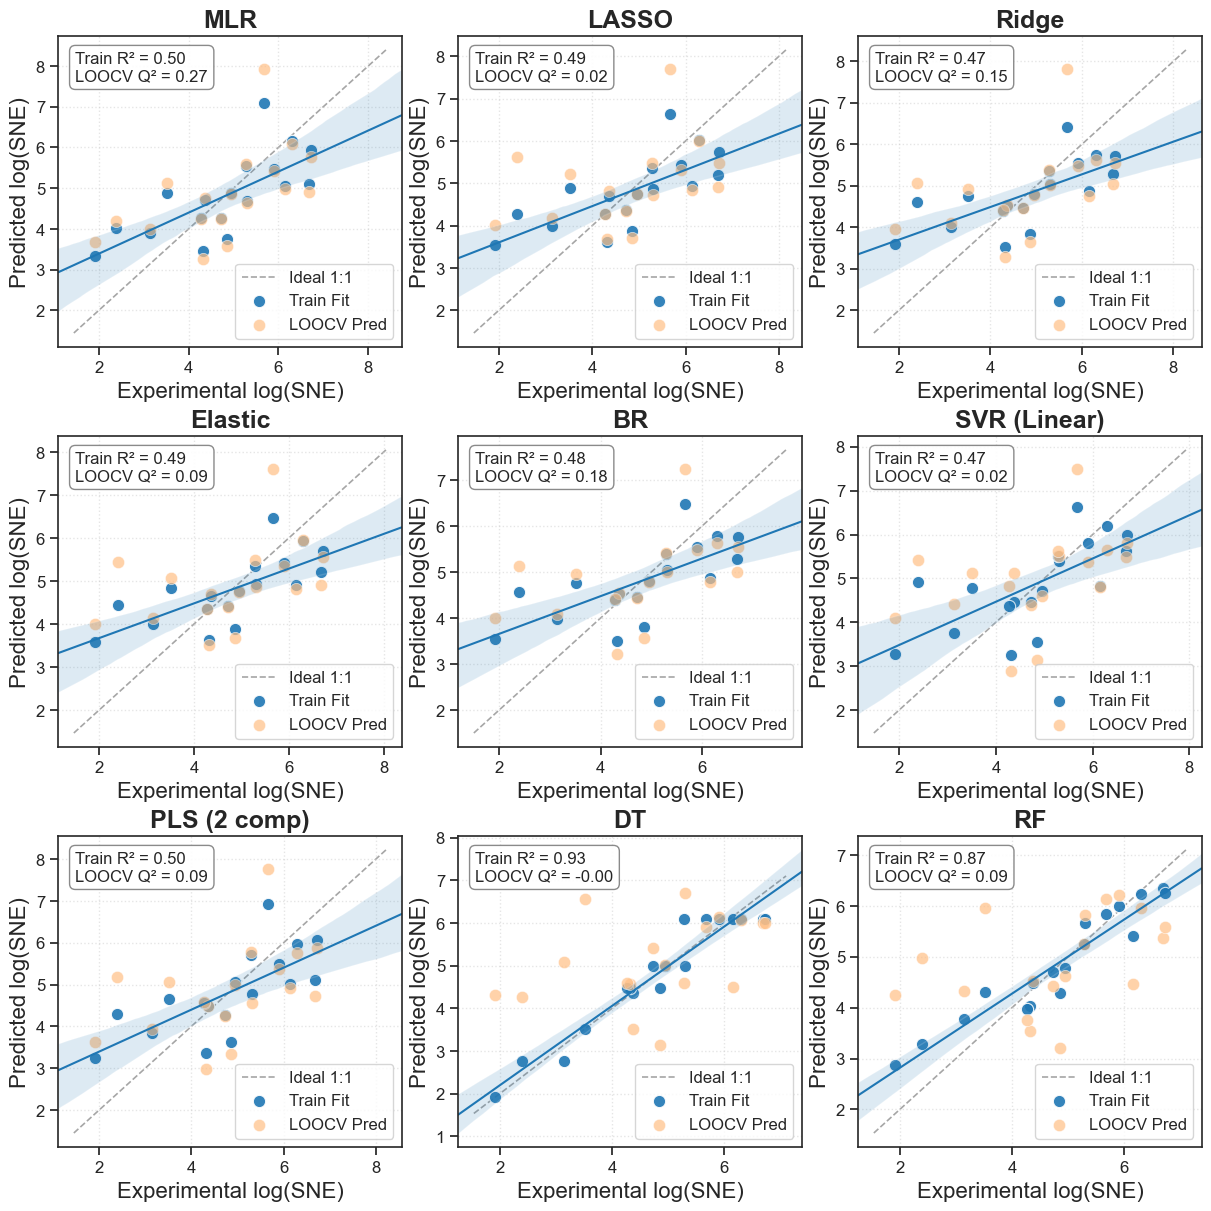

In [10]:
# ==========================================
# 3. 模型定义
# ==========================================
models = {
    "MLR": LinearRegression(n_jobs=-1),
    "LASSO": LassoCV(cv=5, max_iter=10000, random_state=42),
    "Ridge": RidgeCV(cv=5),
    "Elastic": ElasticNetCV(cv=5, max_iter=10000, random_state=42),
    "BR": BayesianRidge(),
    "SVR (Linear)": SVR(kernel='linear', C=1.0),
    "PLS (2 comp)": PLSRegression(n_components=2, max_iter=10000),
    "DT": DecisionTreeRegressor(max_depth=3, random_state=42),
    "RF": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}
X = X_df.copy()
y = y_df.values
loo = LeaveOneOut()

# ==========================================
# 4. 评价函数
# ==========================================
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    pear_r, pear_p = pearsonr(y_true, y_pred)
    spear_rho, spear_p = spearmanr(y_true, y_pred)
    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Pearson_r": pear_r,
        "Pearson_p": pear_p,
        "Spearman_rho": spear_rho,
        "Spearman_p": spear_p
    }
    
# ==========================================
# 5. permutation test
# ==========================================
def permutation_test_loocv_q2(X, y, model, n_permutations=1000, random_state=42):
    rng = np.random.RandomState(random_state)
    pipe = make_pipeline(StandardScaler(), model)
    y_pred_cv = cross_val_predict(pipe, X, y, cv=loo, n_jobs=-1)
    y_pred_cv = np.asarray(y_pred_cv).ravel()
    observed_q2 = r2_score(y, y_pred_cv)
    perm_q2 = []
    for _ in range(n_permutations):
        y_perm = rng.permutation(y)
        y_pred_perm = cross_val_predict(pipe, X, y_perm, cv=loo, n_jobs=-1)
        y_pred_perm = np.asarray(y_pred_perm).ravel()
        q2_perm = r2_score(y_perm, y_pred_perm)
        perm_q2.append(q2_perm)
    perm_q2 = np.array(perm_q2)
    p_value = (np.sum(perm_q2 >= observed_q2) + 1) / (n_permutations + 1)
    return observed_q2, perm_q2, p_value

# ==========================================
# 6. 搜索最佳 MLR
# 以 LOOCV Q² 为主排序依据
# ==========================================
def find_best_mlr_2to3var(X_df, y, candidate_sizes=(2, 3), top_k=None):
    feature_names = X_df.columns.tolist()
    # 可选降维：先按单变量 LOOCV Q² 排名前 top_k 的特征参与组合搜索
    if top_k is not None and top_k < len(feature_names):
        univar_scores = {}
        for col in feature_names:
            pipe = make_pipeline(StandardScaler(), LinearRegression())
            y_pred_cv = cross_val_predict(pipe, X_df[[col]], y, cv=loo, n_jobs=-1)
            y_pred_cv = np.asarray(y_pred_cv).ravel()
            univar_scores[col] = r2_score(y, y_pred_cv)
        feature_names = sorted(univar_scores, key=univar_scores.get, reverse=True)[:top_k]
        print(f"[MLR search] Restricting search to top {top_k} univariate features.")
    results = []
    total_combs = sum(len(list(combinations(feature_names, k))) for k in candidate_sizes)
    print(f"[MLR search] Evaluating total {total_combs} combinations for sizes {candidate_sizes}...")
    for k in candidate_sizes:
        print(f"[MLR search] Searching {k}-variable equations...")
        for feat_tuple in combinations(feature_names, k):
            feat_list = list(feat_tuple)
            X_sub = X_df[feat_list]
            pipe = make_pipeline(StandardScaler(), LinearRegression())
            # Train fit
            pipe.fit(X_sub, y)
            y_pred_train = np.asarray(pipe.predict(X_sub)).ravel()
            train_r2 = r2_score(y, y_pred_train)
            train_mae = mean_absolute_error(y, y_pred_train)
            train_rmse = np.sqrt(mean_squared_error(y, y_pred_train))
            # LOOCV
            y_pred_cv = cross_val_predict(pipe, X_sub, y, cv=loo, n_jobs=-1)
            y_pred_cv = np.asarray(y_pred_cv).ravel()
            cv_q2 = r2_score(y, y_pred_cv)
            cv_mae = mean_absolute_error(y, y_pred_cv)
            cv_rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
            cv_pearson_r, cv_pearson_p = pearsonr(y, y_pred_cv)
            cv_spearman_rho, cv_spearman_p = spearmanr(y, y_pred_cv)
            results.append({
                "features": feat_tuple,
                "N_features": k,
                "Feature_1": feat_list[0],
                "Feature_2": feat_list[1],
                "Feature_3": feat_list[2] if k == 3 else None,
                "Train_R2": train_r2,
                "Train_MAE": train_mae,
                "Train_RMSE": train_rmse,
                "LOOCV_Q2": cv_q2,
                "CV_MAE": cv_mae,
                "CV_RMSE": cv_rmse,
                "CV_Pearson_r": cv_pearson_r,
                "CV_Pearson_p": cv_pearson_p,
                "CV_Spearman_rho": cv_spearman_rho,
                "CV_Spearman_p": cv_spearman_p
            })
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by=["LOOCV_Q2", "CV_RMSE", "N_features", "Train_R2"],
        ascending=[False, True, True, False]
    ).reset_index(drop=True)
    best_row = results_df.iloc[0]
    best_features = list(best_row["features"])
    print("\n[Best MLR equation from 2/3-variable search]")
    print(f"Number of variables: {best_row['N_features']}")
    print(f"Features: {best_features}")
    print(best_row)

    return best_features, results_df

# ==========================================
# 7. 搜索最佳三变量 MLR
# 如果特征很多，可以设置 top_k=15 或 20 加速
# ==========================================
best_mlr_features, mlr_search_results = find_best_mlr_2to3var(
    X_df, y,
    candidate_sizes=(2, 3),
    top_k=None   # 如果运行太慢，可改为 15 或 20
)
print("\nTop 10 best MLR equations (2~3 variables):")
print(mlr_search_results.head(10))


# ==========================================
# 8. 绘图配置
# ==========================================
n_models = len(models)
n_cols = 3
n_rows = ceil(n_models / n_cols)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 4 * n_rows),
    constrained_layout=True
)
axes = axes.flatten()
summary_rows = []
perm_results = {}

print("正在计算并绘制模型对比图...")
# ==========================================
# 9. 主循环
# ==========================================
for i, (name, model) in enumerate(models.items()):
    ax = axes[i]
    # MLR 只使用最佳三变量；其他模型使用全部特征
    if name == "MLR":
        X_model = X_df[best_mlr_features].copy()
    else:
        X_model = X_df.copy()
    pipe = make_pipeline(StandardScaler(), model)
    # 训练集拟合
    pipe.fit(X_model, y)
    y_pred_train = np.asarray(pipe.predict(X_model)).ravel()
    train_metrics = regression_metrics(y, y_pred_train)
    # LOOCV
    y_pred_cv = cross_val_predict(pipe, X_model, y, cv=loo, n_jobs=-1)
    y_pred_cv = np.asarray(y_pred_cv).ravel()
    cv_metrics = regression_metrics(y, y_pred_cv)
    # permutation test
    observed_q2, perm_q2, perm_p = permutation_test_loocv_q2(
        X_model, y, model,
        n_permutations=1000,
        random_state=42
    )
    perm_results[name] = {
        "observed_q2": observed_q2,
        "perm_q2": perm_q2,
        "p_value": perm_p
    }

    # ==========================================
    # 10. 绘图
    # ==========================================
    all_vals = np.concatenate([y, y_pred_train, y_pred_cv])
    low, high = np.min(all_vals), np.max(all_vals)
    margin = (high - low) * 0.08 if high > low else 0.5
    ax.plot(
        [low - margin, high + margin],
        [low - margin, high + margin],
        ls='--', c='gray', alpha=0.7, lw=1.2, zorder=0, label='Ideal 1:1'
    )
    sns.scatterplot(
        x=y, y=y_pred_train, ax=ax,
        color='#1f77b4', s=78, alpha=0.90,
        edgecolor='white', linewidth=0.8,
        label='Train Fit'
    )
    sns.scatterplot(
        x=y, y=y_pred_cv, ax=ax,
        color='#FFBF85', s=78, alpha=0.70,
        edgecolor='white', linewidth=0.5,
        label='LOOCV Pred'
    )
    sns.regplot(
        x=y, y=y_pred_train, ax=ax,
        scatter=False,
        color='#1f77b4',
        line_kws={'linestyle': '-', 'linewidth': 1.5},
        ci=95,
        truncate=False
    )

    stats_text = (
        f"Train R² = {train_metrics['R2']:.2f}\n"
        # f"Train MAE = {train_metrics['MAE']:.2f}\n"
        f"LOOCV Q² = {cv_metrics['R2']:.2f}"
        # f"LOOCV MAE = {cv_metrics['MAE']:.2f}"
    )
    ax.text(
        0.05, 0.95, stats_text,
        transform=ax.transAxes,
        verticalalignment='top',
        fontsize=12,
        bbox=dict(
            boxstyle='round,pad=0.35',
            facecolor='white',
            alpha=0.92,
            edgecolor='gray'
        )
    )
    ax.set_title(name, fontsize=18, fontweight='bold')
    ax.set_xlabel(f"Experimental log({RESPONSE_LABEL})", fontsize=16)
    ax.set_ylabel(f"Predicted log({RESPONSE_LABEL})", fontsize=16)
    ax.legend(loc='lower right', frameon=True, fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.5)
    summary_row = {
        "Model": name,
        "Features_Used": ", ".join(best_mlr_features) if name == "MLR" else "All filtered features",
        "Train_R2": train_metrics["R2"],
        "Train_MAE": train_metrics["MAE"],
        "Train_RMSE": train_metrics["RMSE"],
        "LOOCV_Q2": cv_metrics["R2"],
        "CV_MAE": cv_metrics["MAE"],
        "CV_RMSE": cv_metrics["RMSE"],
        "CV_Pearson_r": cv_metrics["Pearson_r"],
        "CV_Pearson_p": cv_metrics["Pearson_p"],
        "CV_Spearman_rho": cv_metrics["Spearman_rho"],
        "CV_Spearman_p": cv_metrics["Spearman_p"],
        "Permutation_p": perm_p
    }
    # MLR 额外保存系数方程
    if name == "MLR":
        fitted_lr = pipe.named_steps["linearregression"]
        scaler = pipe.named_steps["standardscaler"]
        coefs = fitted_lr.coef_.ravel()
        intercept = fitted_lr.intercept_
        summary_row["MLR_Intercept"] = intercept
        for feat, coef in zip(best_mlr_features, coefs):
            summary_row[f"Coef_{feat}"] = coef
    summary_rows.append(summary_row)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.savefig("./fig/reg_scatter.pdf", dpi=330)
fig.savefig("./fig/reg_scatter.svg", dpi=330)
plt.show()

In [11]:
# ==========================================
# 11. 汇总表
# ==========================================
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(
    by=["LOOCV_Q2", "CV_RMSE"],
    ascending=[False, True]
).reset_index(drop=True)
print("\nModel performance summary:")
print(summary_df)


Model performance summary:
          Model          Features_Used  Train_R2  Train_MAE  Train_RMSE  \
0           MLR    CSD, C#C_C_2_Fukui-  0.504059   0.797730    0.953751   
1            BR  All filtered features  0.478274   0.785822    0.978231   
2         Ridge  All filtered features  0.470021   0.787765    0.985938   
3            RF  All filtered features  0.870620   0.385262    0.487140   
4       Elastic  All filtered features  0.485721   0.791491    0.971224   
5  PLS (2 comp)  All filtered features  0.501563   0.805649    0.956148   
6         LASSO  All filtered features  0.494794   0.792143    0.962619   
7  SVR (Linear)  All filtered features  0.467162   0.745649    0.988594   
8            DT  All filtered features  0.929851   0.278472    0.358699   

   LOOCV_Q2    CV_MAE   CV_RMSE  CV_Pearson_r  CV_Pearson_p  CV_Spearman_rho  \
0  0.267850  0.955453  1.158831      0.563085      0.014969         0.702786   
1  0.178277  0.983284  1.227674      0.461530      0.053855  

In [12]:
# ==========================================
# 12. 输出最佳三变量 MLR 方程
# 注意：这里输出的是标准化空间中的系数
# ==========================================
mlr_row = summary_df[summary_df["Model"] == "MLR"].iloc[0]
print("\nBest 3-variable MLR model:")
print("Features:", best_mlr_features)
print("Intercept (standardized space):", mlr_row.get("MLR_Intercept", np.nan))
for feat in best_mlr_features:
    print(f"{feat}: {mlr_row.get(f'Coef_{feat}', np.nan):.6f}")


Best 3-variable MLR model:
Features: ['CSD', 'C#C_C_2_Fukui-']
Intercept (standardized space): 4.804900083222343
CSD: -0.337016
C#C_C_2_Fukui-: 0.793145


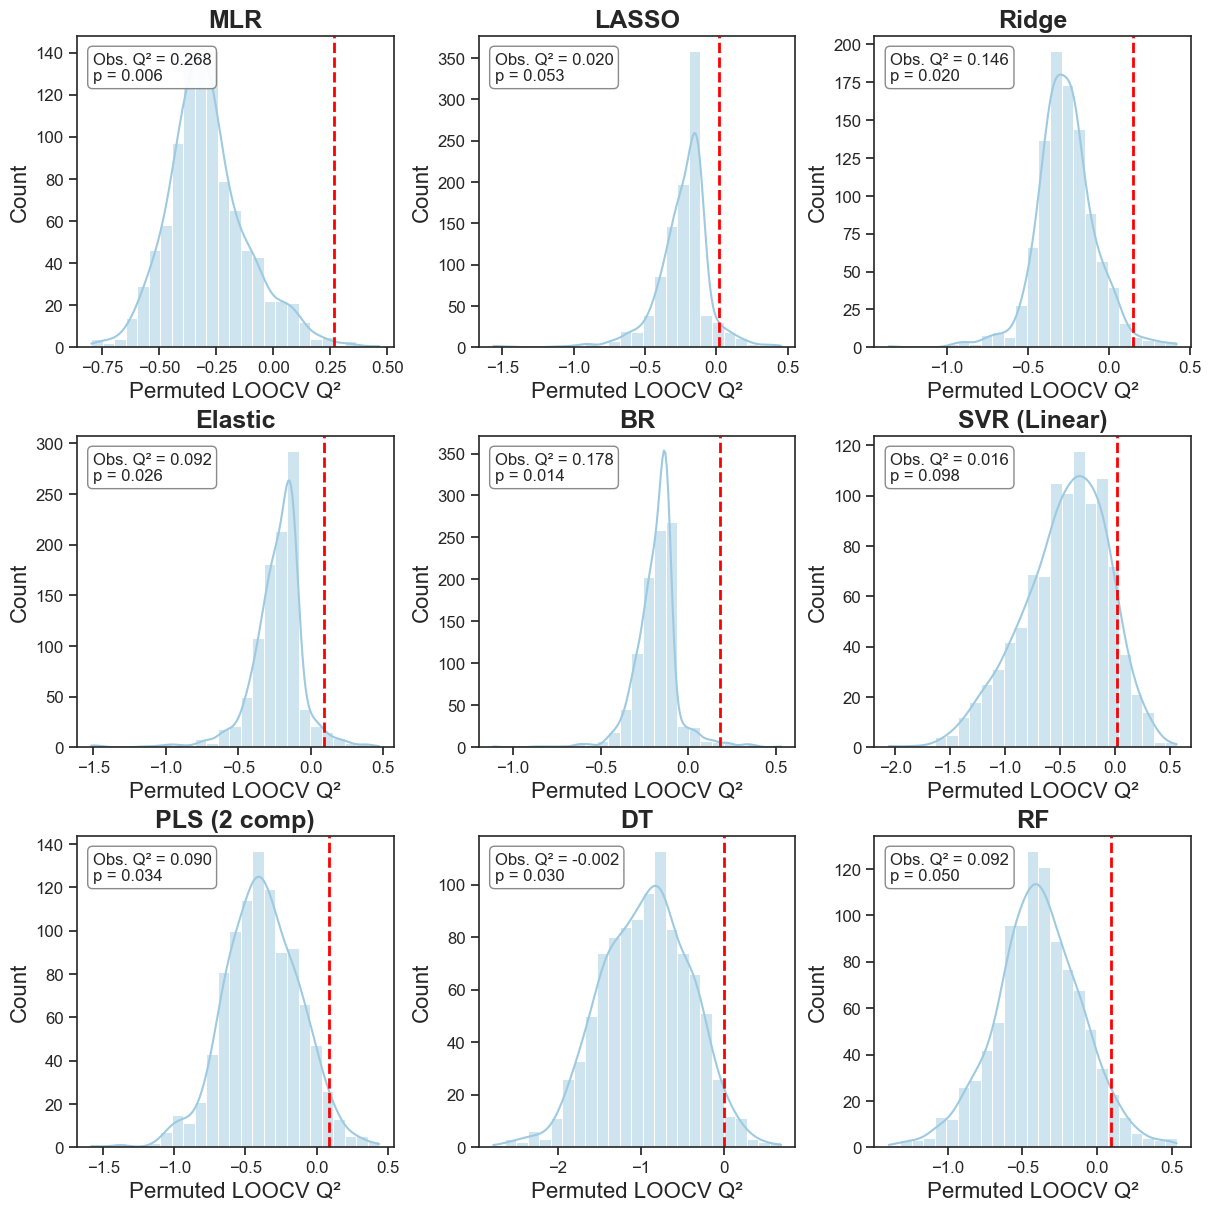

In [13]:
# ==========================================
# 13. permutation test 分布图
# ==========================================
n_perm_models = len(perm_results)
n_cols_perm = 3
n_rows_perm = ceil(n_perm_models / n_cols_perm)
fig, axes = plt.subplots(
    n_rows_perm, n_cols_perm,
    figsize=(4 * n_cols_perm, 4 * n_rows_perm),
    constrained_layout=True
)

axes = axes.flatten()
for i, (name, res) in enumerate(perm_results.items()):
    ax = axes[i]
    sns.histplot(res["perm_q2"], bins=25, kde=True, ax=ax, color="#9ecae1")
    ax.axvline(res["observed_q2"], color="red", linestyle="--", linewidth=2)
    ax.set_title(name, fontsize=18, fontweight='bold')
    ax.set_xlabel("Permuted LOOCV Q²", fontsize=16)
    ax.set_ylabel("Count", fontsize=16)
    ax.text(
        0.05, 0.95,
        f"Obs. Q² = {res['observed_q2']:.3f}\n"
        f"p = {res['p_value']:.3f}",
        transform=ax.transAxes,
        verticalalignment='top',
        fontsize=12,
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            alpha=0.92,
            edgecolor='gray'
        )
    )
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.savefig("./fig/reg_permutation.pdf", dpi=330)
fig.savefig("./fig/reg_permutation.svg", dpi=330)
plt.show()

In [8]:
# 11. 输出总结表格
summary_df.to_csv("model_summary.csv", index=False)
mlr_search_results.to_csv("mlr_3var_search_results.csv", index=False)